In [48]:
#data from: https://github.com/daraei/BikeSafety-/tree/master/BikeSafety

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import networkx as nx
import shapely
import matplotlib.pyplot as plt
import numpy as np

# Clean up csvs (change files with wkt to tab seperated formar)

In [29]:
file = 'edges.csv'
i = 0
data = []
with open(file, 'r', encoding='utf-8') as file:
    for line in file:
        if i == 0:
            cols = line.strip()
            i = 1
        else:
            ls_split = line.strip().split('LINESTRING')
            data_curr = ls_split[0].split(',')[:-1]+['LINESTRING'+ls_split[1]]
            data.append(data_curr)
data_df = pd.DataFrame(data, columns=cols.replace('"', '').split(','))
data_df.to_csv('edges_2.csv')

In [30]:
file = 'edges(1).csv'
i = 0
data = []
with open(file, 'r', encoding='utf-8') as file:
    for line in file:
        if i == 0:
            cols = line.strip()
            i = 1
        else:
            ls_split = line.strip().split('LINESTRING')
            data_curr = ls_split[0].split(',')[:-1]+['LINESTRING'+ls_split[1]]
            data.append(data_curr)
data_df = pd.DataFrame(data, columns=cols.replace('"', '').split(','))
data_df.to_csv('edges(1)_2.csv')

In [45]:
file = 'random1.csv'
i = 0
data = []
with open(file, 'r', encoding='utf-8') as file:
    for line in file:
        if i == 0:
            cols = line.strip()
            i = 1
        else:
            #print(line.strip())
            ls_split = line.strip().split('LINESTRING')
            part1 = ls_split[0].split(',')[:-1]
            part23 = ls_split[1].split(')')
            part2 = ['LINESTRING'+part23[0].replace('"', '')+')']
            part3 = part23[1].split(',')[-4:]
            data_curr = part1 +part2+part3
            #print(data_curr)
            data.append(data_curr)
data_df = pd.DataFrame(data, columns=cols.replace('"', '').split(',')[:10]+cols.replace('"', '').split(',')[-4:])
data_df.to_csv('random1_2.csv')

# Combine some files to set up for regression

In [2]:
collisions = pd.read_csv('collision.csv')
collisions = gpd.GeoDataFrame(collisions, geometry=gpd.points_from_xy(collisions['LONGITUDE'], collisions['LATITUDE']), crs='EPSG:4326')
collisions

,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,severity,carLane,bikeLane,streetLength,car.reverse,bike.reverse,foot,geometry
0,2004004844,2004,4,3,99.0,0,3,-79.968000,40.532500,30.0,serious,0,5,111.394508,0,5,1,POINT (-79.96800 40.53250)
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,slight,0,5,662.396118,0,5,1,POINT (-79.90620 40.38560)
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,serious,0,5,993.741943,0,5,1,POINT (-80.02460 40.40870)
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,serious,1,2,523.535828,1,2,1,POINT (-79.90300 40.40910)
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,fatal,0,5,993.741943,0,5,1,POINT (-79.94810 40.41870)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,unknown,2,2,1647.338135,2,2,1,POINT (-79.84030 40.47830)
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,serious,0,5,111.394508,0,5,1,POINT (-79.94980 40.46420)
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,unknown,1,2,245.413177,1,2,1,POINT (-80.00350 40.45290)
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,unknown,0,5,29.429888,0,5,1,POINT (-79.94560 40.44450)


In [3]:
edges = pd.read_csv('edges_2.csv')
geometry_series = edges['WKT'].apply(wkt.loads)
edges = gpd.GeoDataFrame(edges, geometry=geometry_series, crs="EPSG:4326")
edges['length2'] = edges.length
edges

C:\Users\cle9a\AppData\Local\Temp\ipykernel_27448\1927821078.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edges['length2'] = edges.length


,Unnamed: 0,edge_id,source,target,length,car,car reverse,bike,bike reverse,foot,WKT,geometry,length2
0,0,0,104185739,104185746,38.786385,1,1,2,2,1,"LINESTRING(-80.0399041 40.4444611,-80.0395987 ...","LINESTRING (-80.03990 40.44446, -80.03960 40.4...",0.000401
1,1,1,104185746,104185749,82.869324,1,1,2,2,1,"LINESTRING(-80.0395987 40.444201,-80.0389524 4...","LINESTRING (-80.03960 40.44420, -80.03895 40.4...",0.000855
2,2,2,104185749,104185758,24.761192,1,1,2,2,1,"LINESTRING(-80.0389524 40.4436411,-80.0387703 ...","LINESTRING (-80.03895 40.44364, -80.03877 40.4...",0.000252
3,3,3,104185772,104185781,103.952202,1,1,2,2,1,"LINESTRING(-79.8406686 40.5007586,-79.8394403 ...","LINESTRING (-79.84067 40.50076, -79.83944 40.5...",0.001229
4,4,4,104185781,104185788,157.893753,1,1,2,2,1,"LINESTRING(-79.8394403 40.5007989,-79.8375759 ...","LINESTRING (-79.83944 40.50080, -79.83758 40.5...",0.001866
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80808,80808,80808,3196478437,5312909809,7.365902,0,0,5,5,1,"LINESTRING(-79.9966397 40.4394043,-79.9966954 ...","LINESTRING (-79.99664 40.43940, -79.99670 40.4...",0.000075
80809,80809,80809,5417356642,5618072218,40.879318,0,0,5,5,1,"LINESTRING(-79.9961366 40.4392193,-79.9957007 ...","LINESTRING (-79.99614 40.43922, -79.99570 40.4...",0.000464
80810,80810,80810,5618072218,5312909816,12.516347,0,0,5,5,1,"LINESTRING(-79.9957007 40.4390609,-79.9955539 ...","LINESTRING (-79.99570 40.43906, -79.99555 40.4...",0.000147
80811,80811,80811,5618072218,5312909817,6.984038,0,0,5,5,1,"LINESTRING(-79.9957007 40.4390609,-79.9957075 ...","LINESTRING (-79.99570 40.43906, -79.99571 40.4...",0.000063


In [21]:
geoSmooth = pd.read_csv('geoSmooth.csv')
geoSmooth

,edge_id,length,car,car.reverse,bike,bike.reverse,foot,saftyScore,betweenness,Speed_limit,Hilliness,lss,logbetweenness,residuals,predicted,logbetweennesst
0,258,14.930519,0,0,5,5,1,1.0,2.000000,30,flat,1,0.000000,2.220446e-16,0.993973,0.000000
1,229,40.370461,1,1,2,2,1,1.0,38.000000,25,up,1,0.000000,3.822834e-02,0.934834,0.000000
2,70,523.535828,1,1,2,2,1,1.0,2.000000,25,down,1,0.000000,1.838249e-02,0.996354,0.000000
3,28,50.893288,1,1,2,2,1,1.0,454.000000,35,flat,1,5.851331,3.829761e-03,0.992538,5.851331
4,36,109.275681,1,1,2,2,1,1.0,17.166667,25,flat,1,0.000000,1.726050e-03,0.997325,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,2011058798,38.231808,1,1,2,2,1,1.0,30.000000,25,up,1,0.000000,3.937274e-02,0.933376,0.000000
214,2013045332,7.990372,1,1,2,2,1,0.0,753.166667,20,up,0,5.851331,-9.394181e-01,0.858420,5.851331
215,2016083706,80.116333,1,1,2,2,1,0.0,2459.000000,25,up,0,5.851331,-9.780223e-01,0.933418,5.851331
216,2015119084,12.367122,2,2,2,2,1,0.0,785.000000,25,up,0,5.851331,-5.144468e-01,0.212851,5.851331


In [26]:
edgesAtt = pd.merge(edges, geoSmooth, on='edge_id', how='right')
edgesAtt

,Unnamed: 0,edge_id,source,target,length_x,car_x,car reverse,bike_x,bike reverse,foot_x,...,foot_y,saftyScore,betweenness,Speed_limit,Hilliness,lss,logbetweenness,residuals,predicted,logbetweennesst
0,258.0,258,1.042013e+08,1.042013e+08,74.547981,1.0,1.0,2.0,2.0,1.0,...,1,1.0,2.000000,30,flat,1,0.000000,2.220446e-16,0.993973,0.000000
1,229.0,229,5.372791e+09,2.629522e+09,14.730581,1.0,1.0,2.0,2.0,1.0,...,1,1.0,38.000000,25,up,1,0.000000,3.822834e-02,0.934834,0.000000
2,70.0,70,4.504392e+09,4.504392e+09,224.712982,1.0,1.0,2.0,2.0,1.0,...,1,1.0,2.000000,25,down,1,0.000000,1.838249e-02,0.996354,0.000000
3,28.0,28,1.041863e+08,1.041863e+08,268.227844,2.0,2.0,2.0,2.0,1.0,...,1,1.0,454.000000,35,flat,1,5.851331,3.829761e-03,0.992538,5.851331
4,36.0,36,1.041864e+08,3.652971e+09,125.648445,1.0,1.0,2.0,2.0,1.0,...,1,1.0,17.166667,25,flat,1,0.000000,1.726050e-03,0.997325,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,NaN,2011058798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1.0,30.000000,25,up,1,0.000000,3.937274e-02,0.933376,0.000000
214,NaN,2013045332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0.0,753.166667,20,up,0,5.851331,-9.394181e-01,0.858420,5.851331
215,NaN,2016083706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0.0,2459.000000,25,up,0,5.851331,-9.780223e-01,0.933418,5.851331
216,NaN,2015119084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0.0,785.000000,25,up,0,5.851331,-5.144468e-01,0.212851,5.851331


In [27]:
edgesAtt[['car_x', 'car_y']]

,car_x,car_y
0,1.0,0
1,1.0,1
2,1.0,1
3,2.0,1
4,1.0,1
...,...,...
213,NaN,1
214,NaN,1
215,NaN,1
216,NaN,2


The edge_ids don't seem to match up.

### Combine collision with road

In [4]:
utm_crs = collisions.estimate_utm_crs(datum_name='WGS 84')
collisions = collisions.to_crs(utm_crs)
edges = edges.to_crs(utm_crs)
edges['length_direct_calc'] = edges.length
coll_road = gpd.sjoin_nearest(collisions, edges, how="left", distance_col="dist_to_road")
coll_road

,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,...,length,car,car reverse,bike,bike reverse,foot_right,WKT,length2,length_direct_calc,dist_to_road
0,2004004844,2004,4,3,99.0,0,3,-79.968000,40.532500,30.0,...,1164.616089,3,3,2,2,1,"LINESTRING(-79.9705448 40.535689,-79.9696333 4...",0.011419,1163.858011,0.950890
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,...,42.773911,1,1,2,2,1,"LINESTRING(-79.9057444 40.3856539,-79.9062379 ...",0.000500,42.862069,2.335425
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,...,42.537609,1,1,2,2,1,"LINESTRING(-80.0246393 40.4090417,-80.0246376 ...",0.000383,42.466049,2.713114
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,...,65.745750,4,0,2,0,1,"LINESTRING(-79.9028033 40.4090652,-79.9029351 ...",0.000668,65.735639,5.042122
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,...,1076.347168,4,4,2,2,1,"LINESTRING(-79.9467276 40.4160144,-79.9476047 ...",0.010272,1075.280734,0.053449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,...,206.698410,3,3,2,2,1,"LINESTRING(-79.84225 40.4777271,-79.8399869 40...",0.002369,207.049767,3.383417
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,...,26.270502,1,1,2,2,1,"LINESTRING(-79.9496083 40.4643432,-79.9498223 ...",0.000274,26.275600,0.620458
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,...,19.869846,0,0,5,5,1,"LINESTRING(-80.0035449 40.45307,-80.0035028 40...",0.000181,19.839194,0.190372
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,...,2.978004,0,0,5,5,1,"LINESTRING(-79.9455705 40.4444804,-79.9455677 ...",0.000027,2.973457,3.471096


In [14]:
coll_road.columns

Index(['CRASH_CRN', 'CRASH_YEAR', 'CRASH_MONTH', 'DAY_OF_WEEK', 'HOUR_OF_DAY',
       'LOCATION_TYPE', 'MAX_SEVERITY_LEVEL', 'LONGITUDE', 'LATITUDE',
       'SPEED_LIMIT', 'severity', 'carLane', 'bikeLane', 'streetLength',
       'car.reverse', 'bike.reverse', 'foot_left', 'geometry', 'index_right',
       'Unnamed: 0', 'edge_id', 'source', 'target', 'length', 'car',
       'car reverse', 'bike', 'bike reverse', 'foot_right', 'WKT',
       'dist_to_road'],
      dtype='object')

In [17]:
coll_road[['car.reverse', 'carLane', 'car reverse', 'car']]

,car.reverse,carLane,car reverse,car
0,0,0,3,3
1,0,0,1,1
2,0,0,1,1
3,1,1,0,4
4,0,0,4,4
...,...,...,...,...
1072,2,2,3,3
1073,0,0,1,1
1074,1,1,0,0
1075,0,0,0,0


In [19]:
coll_road[['bikeLane', 'bike.reverse', 'bike', 'bike reverse']]

,bikeLane,bike.reverse,bike,bike reverse
0,5,5,2,2
1,5,5,2,2
2,5,5,2,2
3,2,2,2,0
4,5,5,2,2
...,...,...,...,...
1072,2,2,2,2
1073,5,5,2,2
1074,2,2,5,5
1075,5,5,5,5


data is still not lining up...

which is right? or what do they mean?

spot check with 40.4187, -79.9481, Iving Street (collision point didnt' make sense, says no cars, there is a bike trail vaguely nearby)


some vaules (like street length doesn't change for points that are clearly not on the same road)

In [30]:
G = nx.from_pandas_edgelist(edges, source='source', target='target', edge_attr='edge_id')
edge_centralities = nx.edge_betweenness_centrality(G, k = 100, normalized = True)
edge_centralities

{(104185739, 104185746): 1.3424661981399091e-08,
 (104185739, 105697570): 1.4350513295869183e-08,
 (104185739, 104678799): 3.290483107199656e-08,
 (104185746, 104185749): 2.474832673089861e-08,
 (104185746, 104678790): 2.19542441605821e-08,
 (104185746, 105690043): 1.4341985141576148e-08,
 (104185749, 104185758): 2.7178799721841293e-08,
 (104185749, 104628945): 1.0151292822494902e-07,
 (104185749, 104628962): 4.986033510273282e-08,
 (104185772, 104185781): 4.15783406524301e-07,
 (104185772, 105783514): 2.7178799721841293e-08,
 (104185772, 104731730): 4.6747411075718236e-07,
 (104185781, 104185788): 3.6671514924870753e-07,
 (104185781, 105201227): 2.7178799721841293e-08,
 (104185781, 105201231): 1.720408871281536e-09,
 (104185788, 104541755): 1.0804425186622126e-06,
 (104185788, 104541764): 7.395335024827276e-07,
 (104185798, 104185808): 3.403948169471509e-06,
 (104185798, 104605785): 1.1418141883175997e-06,
 (104185798, 2505562845): 4.415497520540404e-06,
 (104185808, 104934842): 2.909

In [40]:
edges['tuple_st'] = edges[['source', 'target']].apply(tuple, axis=1)
edges['betweenness'] = edges['tuple_st'].apply(lambda x: edge_centralities[x] if x in edge_centralities.keys() else 0)
edges

,Unnamed: 0,edge_id,source,target,length,car,car reverse,bike,bike reverse,foot,WKT,geometry,tuple_st,betweenness
0,0,0,104185739,104185746,38.786385,1,1,2,2,1,"LINESTRING(-80.0399041 40.4444611,-80.0395987 ...","LINESTRING (581420.291 4477532.508, 581446.505...","(104185739, 104185746)",1.342466e-08
1,1,1,104185746,104185749,82.869324,1,1,2,2,1,"LINESTRING(-80.0395987 40.444201,-80.0389524 4...","LINESTRING (581446.505 4477503.918, 581501.991...","(104185746, 104185749)",2.474833e-08
2,2,2,104185749,104185758,24.761192,1,1,2,2,1,"LINESTRING(-80.0389524 40.4436411,-80.0387703 ...","LINESTRING (581501.991 4477442.365, 581517.645...","(104185749, 104185758)",2.717880e-08
3,3,3,104185772,104185781,103.952202,1,1,2,2,1,"LINESTRING(-79.8406686 40.5007586,-79.8394403 ...","LINESTRING (598234.577 4483984.446, 598338.599...","(104185772, 104185781)",4.157834e-07
4,4,4,104185781,104185788,157.893753,1,1,2,2,1,"LINESTRING(-79.8394403 40.5007989,-79.8375759 ...","LINESTRING (598338.599 4483990.288, 598496.462...","(104185781, 104185788)",3.667151e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80808,80808,80808,3196478437,5312909809,7.365902,0,0,5,5,1,"LINESTRING(-79.9966397 40.4394043,-79.9966954 ...","LINESTRING (585095.736 4477011.983, 585091.076...","(3196478437, 5312909809)",0.000000e+00
80809,80809,80809,5417356642,5618072218,40.879318,0,0,5,5,1,"LINESTRING(-79.9961366 40.4392193,-79.9957007 ...","LINESTRING (585138.638 4476991.932, 585175.808...","(5417356642, 5618072218)",9.667629e-09
80810,80810,80810,5618072218,5312909816,12.516347,0,0,5,5,1,"LINESTRING(-79.9957007 40.4390609,-79.9955539 ...","LINESTRING (585175.808 4476974.770, 585188.241...","(5618072218, 5312909816)",0.000000e+00
80811,80811,80811,5618072218,5312909817,6.984038,0,0,5,5,1,"LINESTRING(-79.9957007 40.4390609,-79.9957075 ...","LINESTRING (585175.808 4476974.770, 585175.310...","(5618072218, 5312909817)",0.000000e+00


In [5]:
coll_road = gpd.sjoin_nearest(collisions, edges, how="left", distance_col="dist_to_road")
coll_road

,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,...,length,car,car reverse,bike,bike reverse,foot_right,WKT,length2,length_direct_calc,dist_to_road
0,2004004844,2004,4,3,99.0,0,3,-79.968000,40.532500,30.0,...,1164.616089,3,3,2,2,1,"LINESTRING(-79.9705448 40.535689,-79.9696333 4...",0.011419,1163.858011,0.950890
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,...,42.773911,1,1,2,2,1,"LINESTRING(-79.9057444 40.3856539,-79.9062379 ...",0.000500,42.862069,2.335425
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,...,42.537609,1,1,2,2,1,"LINESTRING(-80.0246393 40.4090417,-80.0246376 ...",0.000383,42.466049,2.713114
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,...,65.745750,4,0,2,0,1,"LINESTRING(-79.9028033 40.4090652,-79.9029351 ...",0.000668,65.735639,5.042122
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,...,1076.347168,4,4,2,2,1,"LINESTRING(-79.9467276 40.4160144,-79.9476047 ...",0.010272,1075.280734,0.053449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,...,206.698410,3,3,2,2,1,"LINESTRING(-79.84225 40.4777271,-79.8399869 40...",0.002369,207.049767,3.383417
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,...,26.270502,1,1,2,2,1,"LINESTRING(-79.9496083 40.4643432,-79.9498223 ...",0.000274,26.275600,0.620458
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,...,19.869846,0,0,5,5,1,"LINESTRING(-80.0035449 40.45307,-80.0035028 40...",0.000181,19.839194,0.190372
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,...,2.978004,0,0,5,5,1,"LINESTRING(-79.9455705 40.4444804,-79.9455677 ...",0.000027,2.973457,3.471096


In [45]:
#add nodes to get distance
#actually, can't just do this because what if closest intersection is on a different road?
#check distance to start and end nodes instead
#nodes = pd.read_csv('nodes.csv')
#nodes = gpd.GeoDataFrame(nodes, geometry=gpd.points_from_xy(nodes['longitude'], nodes['latitude']), crs='EPSG:4326')
#nodes = nodes.to_crs(utm_crs)
#coll_road = coll_road.rename(columns={'index_left': 'cr_index_left', 'index_right': 'cr_index_right'})
#coll_road_node = gpd.sjoin_nearest(coll_road, nodes, how="left",  distance_col="dist_to_node")
#coll_road_node

,node_id,longitude,latitude,geometry
0,5618072218,-79.995701,40.439061,POINT (585175.808 4476974.770)
1,5618072217,-79.996206,40.440067,POINT (585131.691 4477085.961)
2,5607202657,-80.045800,40.425539,POINT (580943.000 4475426.749)
3,5607202655,-80.045155,40.425403,POINT (580997.819 4475412.211)
4,5607199881,-80.046113,40.426067,POINT (580915.791 4475485.004)
...,...,...,...,...
60403,2744078383,-80.113492,40.458539,POINT (575163.947 4479029.903)
60404,109404706,-79.722032,40.402970,POINT (608444.457 4473268.471)
60405,105048469,-79.818301,40.395087,POINT (600286.925 4472279.728)
60406,4618543122,-79.935415,40.510462,POINT (590193.191 4484960.325)


In [6]:
#check distance to start and end nodes instead
coll_road["end1"] = coll_road['edge_id'].apply(lambda x: shapely.geometry.Point(edges[edges['edge_id'] == x]['geometry'].values[0].coords[0]))
coll_road["end2"] = coll_road['edge_id'].apply(lambda x: shapely.geometry.Point(edges[edges['edge_id'] == x]['geometry'].values[0].coords[-1]))
coll_road

,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,...,car reverse,bike,bike reverse,foot_right,WKT,length2,length_direct_calc,dist_to_road,end1,end2
0,2004004844,2004,4,3,99.0,0,3,-79.968000,40.532500,30.0,...,3,2,2,1,"LINESTRING(-79.9705448 40.535689,-79.9696333 4...",0.011419,1163.858011,0.950890,POINT (587184.2045291621 4487725.289020367),POINT (587788.5113626159 4486730.782951104)
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,...,1,2,2,1,"LINESTRING(-79.9057444 40.3856539,-79.9062379 ...",0.000500,42.862069,2.335425,POINT (592878.6581699251 4471137.155376474),POINT (592836.8820386755 4471127.568312301)
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,...,1,2,2,1,"LINESTRING(-80.0246393 40.4090417,-80.0246376 ...",0.000383,42.466049,2.713114,POINT (582758.2380461905 4473615.1039408995),POINT (582759.4023933862 4473572.653857757)
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,...,0,2,0,1,"LINESTRING(-79.9028033 40.4090652,-79.9029351 ...",0.000668,65.735639,5.042122,POINT (593096.043734049 4473738.9305558745),POINT (593056.5549910507 4473788.298799102)
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,...,4,2,2,1,"LINESTRING(-79.9467276 40.4160144,-79.9476047 ...",0.010272,1075.280734,0.053449,POINT (589359.8476104012 4474464.955173336),POINT (588900.5070527779 4475435.921122406)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,...,3,2,2,1,"LINESTRING(-79.84225 40.4777271,-79.8399869 40...",0.002369,207.049767,3.383417,POINT (598134.1234259857 4481426.114916734),POINT (598324.9307172929 4481506.502625698)
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,...,1,2,2,1,"LINESTRING(-79.9496083 40.4643432,-79.9498223 ...",0.000274,26.275600,0.620458,POINT (589051.6431965053 4479826.624092405),POINT (589033.7261411783 4479807.404667096)
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,...,0,5,5,1,"LINESTRING(-80.0035449 40.45307,-80.0035028 40...",0.000181,19.839194,0.190372,POINT (584492.9748069715 4478522.265655498),POINT (584496.7649014959 4478502.791857467)
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,...,0,5,5,1,"LINESTRING(-79.9455705 40.4444804,-79.9455677 ...",0.000027,2.973457,3.471096,POINT (589420.3021206178 4477625.895289609),POINT (589420.5749638614 4477622.934377096)


In [7]:
coll_road['end1_dist'] = coll_road['geometry'].distance(gpd.GeoSeries(coll_road['end1']))
coll_road['end2_dist'] = coll_road['geometry'].distance(gpd.GeoSeries(coll_road['end2']))
coll_road['dist_to_int'] = coll_road[['end1_dist', 'end2_dist']].min(axis=1)
coll_road

C:\Users\cle9a\AppData\Local\Temp\ipykernel_27448\4147783513.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:32617
Right CRS: None

  coll_road['end1_dist'] = coll_road['geometry'].distance(gpd.GeoSeries(coll_road['end1']))
C:\Users\cle9a\AppData\Local\Temp\ipykernel_27448\4147783513.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:32617
Right CRS: None

  coll_road['end2_dist'] = coll_road['geometry'].distance(gpd.GeoSeries(coll_road['end2']))


,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,...,foot_right,WKT,length2,length_direct_calc,dist_to_road,end1,end2,end1_dist,end2_dist,dist_to_int
0,2004004844,2004,4,3,99.0,0,3,-79.968000,40.532500,30.0,...,1,"LINESTRING(-79.9705448 40.535689,-79.9696333 4...",0.011419,1163.858011,0.950890,POINT (587184.2045291621 4487725.289020367),POINT (587788.5113626159 4486730.782951104),414.468344,749.296014,414.468344
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,...,1,"LINESTRING(-79.9057444 40.3856539,-79.9062379 ...",0.000500,42.862069,2.335425,POINT (592878.6581699251 4471137.155376474),POINT (592836.8820386755 4471127.568312301),39.134453,4.458047,4.458047
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,...,1,"LINESTRING(-80.0246393 40.4090417,-80.0246376 ...",0.000383,42.466049,2.713114,POINT (582758.2380461905 4473615.1039408995),POINT (582759.4023933862 4473572.653857757),38.077557,5.241868,5.241868
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,...,1,"LINESTRING(-79.9028033 40.4090652,-79.9029351 ...",0.000668,65.735639,5.042122,POINT (593096.043734049 4473738.9305558745),POINT (593056.5549910507 4473788.298799102),17.132632,51.061075,17.132632
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,...,1,"LINESTRING(-79.9467276 40.4160144,-79.9476047 ...",0.010272,1075.280734,0.053449,POINT (589359.8476104012 4474464.955173336),POINT (588900.5070527779 4475435.921122406),320.059565,754.832473,320.059565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,...,1,"LINESTRING(-79.84225 40.4777271,-79.8399869 40...",0.002369,207.049767,3.383417,POINT (598134.1234259857 4481426.114916734),POINT (598324.9307172929 4481506.502625698),176.925501,30.345828,30.345828
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,...,1,"LINESTRING(-79.9496083 40.4643432,-79.9498223 ...",0.000274,26.275600,0.620458,POINT (589051.6431965053 4479826.624092405),POINT (589033.7261411783 4479807.404667096),22.721766,3.615937,3.615937
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,...,1,"LINESTRING(-80.0035449 40.45307,-80.0035028 40...",0.000181,19.839194,0.190372,POINT (584492.9748069715 4478522.265655498),POINT (584496.7649014959 4478502.791857467),19.228327,0.640744,0.640744
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,...,1,"LINESTRING(-79.9455705 40.4444804,-79.9455677 ...",0.000027,2.973457,3.471096,POINT (589420.3021206178 4477625.895289609),POINT (589420.5749638614 4477622.934377096),3.471096,5.920633,3.471096


In [8]:
#calculate curve or road (source to target length/edge length)
coll_road['straight_len'] = gpd.GeoSeries(coll_road['end1']).distance(gpd.GeoSeries(coll_road['end2']))
coll_road

,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,...,WKT,length2,length_direct_calc,dist_to_road,end1,end2,end1_dist,end2_dist,dist_to_int,straight_len
0,2004004844,2004,4,3,99.0,0,3,-79.968000,40.532500,30.0,...,"LINESTRING(-79.9705448 40.535689,-79.9696333 4...",0.011419,1163.858011,0.950890,POINT (587184.2045291621 4487725.289020367),POINT (587788.5113626159 4486730.782951104),414.468344,749.296014,414.468344,1163.713483
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,...,"LINESTRING(-79.9057444 40.3856539,-79.9062379 ...",0.000500,42.862069,2.335425,POINT (592878.6581699251 4471137.155376474),POINT (592836.8820386755 4471127.568312301),39.134453,4.458047,4.458047,42.862069
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,...,"LINESTRING(-80.0246393 40.4090417,-80.0246376 ...",0.000383,42.466049,2.713114,POINT (582758.2380461905 4473615.1039408995),POINT (582759.4023933862 4473572.653857757),38.077557,5.241868,5.241868,42.466048
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,...,"LINESTRING(-79.9028033 40.4090652,-79.9029351 ...",0.000668,65.735639,5.042122,POINT (593096.043734049 4473738.9305558745),POINT (593056.5549910507 4473788.298799102),17.132632,51.061075,17.132632,63.218544
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,...,"LINESTRING(-79.9467276 40.4160144,-79.9476047 ...",0.010272,1075.280734,0.053449,POINT (589359.8476104012 4474464.955173336),POINT (588900.5070527779 4475435.921122406),320.059565,754.832473,320.059565,1074.136221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,...,"LINESTRING(-79.84225 40.4777271,-79.8399869 40...",0.002369,207.049767,3.383417,POINT (598134.1234259857 4481426.114916734),POINT (598324.9307172929 4481506.502625698),176.925501,30.345828,30.345828,207.049767
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,...,"LINESTRING(-79.9496083 40.4643432,-79.9498223 ...",0.000274,26.275600,0.620458,POINT (589051.6431965053 4479826.624092405),POINT (589033.7261411783 4479807.404667096),22.721766,3.615937,3.615937,26.275600
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,...,"LINESTRING(-80.0035449 40.45307,-80.0035028 40...",0.000181,19.839194,0.190372,POINT (584492.9748069715 4478522.265655498),POINT (584496.7649014959 4478502.791857467),19.228327,0.640744,0.640744,19.839194
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,...,"LINESTRING(-79.9455705 40.4444804,-79.9455677 ...",0.000027,2.973457,3.471096,POINT (589420.3021206178 4477625.895289609),POINT (589420.5749638614 4477622.934377096),3.471096,5.920633,3.471096,2.973457


In [9]:
coll_road['curve'] = coll_road['length_direct_calc']/coll_road['straight_len']
coll_road

,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,...,length2,length_direct_calc,dist_to_road,end1,end2,end1_dist,end2_dist,dist_to_int,straight_len,curve
0,2004004844,2004,4,3,99.0,0,3,-79.968000,40.532500,30.0,...,0.011419,1163.858011,0.950890,POINT (587184.2045291621 4487725.289020367),POINT (587788.5113626159 4486730.782951104),414.468344,749.296014,414.468344,1163.713483,1.000124
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,...,0.000500,42.862069,2.335425,POINT (592878.6581699251 4471137.155376474),POINT (592836.8820386755 4471127.568312301),39.134453,4.458047,4.458047,42.862069,1.000000
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,...,0.000383,42.466049,2.713114,POINT (582758.2380461905 4473615.1039408995),POINT (582759.4023933862 4473572.653857757),38.077557,5.241868,5.241868,42.466048,1.000000
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,...,0.000668,65.735639,5.042122,POINT (593096.043734049 4473738.9305558745),POINT (593056.5549910507 4473788.298799102),17.132632,51.061075,17.132632,63.218544,1.039816
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,...,0.010272,1075.280734,0.053449,POINT (589359.8476104012 4474464.955173336),POINT (588900.5070527779 4475435.921122406),320.059565,754.832473,320.059565,1074.136221,1.001066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,...,0.002369,207.049767,3.383417,POINT (598134.1234259857 4481426.114916734),POINT (598324.9307172929 4481506.502625698),176.925501,30.345828,30.345828,207.049767,1.000000
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,...,0.000274,26.275600,0.620458,POINT (589051.6431965053 4479826.624092405),POINT (589033.7261411783 4479807.404667096),22.721766,3.615937,3.615937,26.275600,1.000000
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,...,0.000181,19.839194,0.190372,POINT (584492.9748069715 4478522.265655498),POINT (584496.7649014959 4478502.791857467),19.228327,0.640744,0.640744,19.839194,1.000000
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,...,0.000027,2.973457,3.471096,POINT (589420.3021206178 4477625.895289609),POINT (589420.5749638614 4477622.934377096),3.471096,5.920633,3.471096,2.973457,1.000000


In [55]:
coll_road.sort_values(by = 'curve')['edge_id']

1076    17588
404     52704
405      2818
406     57616
798     18862
        ...  
452     45377
561     45377
107     45377
731     66968
643     21045
Name: edge_id, Length: 1077, dtype: int64

(array([868.,  57.,  40.,   2.,  28.,  30.,   0.,   1.,   6.,   0.,   2.,
         25.,   2.,   3.,   0.,   0.,   1.,   1.,   0.,   2.,   1.,   0.,
          0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   4.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.        , 0.0163508 , 0.0327016 , 0.0490524 , 0.0654032 ,
        0.081754  , 0.0981048 , 0.1144556 , 0.1308064 , 0.14715721,
        0.16350801, 0.17985881, 0.19620961, 0.21256041, 0.22891121,
        0.24526201, 0.26161281, 0.27796361, 0.29431441, 0.31066521,
        0.32701601, 0.34336681, 0.35971761, 0.

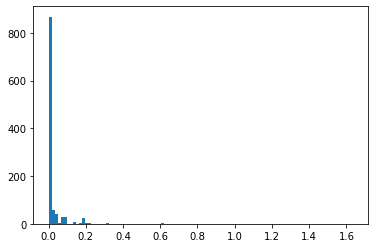

In [49]:
plt.hist(np.log(coll_road['curve']), bins = 100)

In [50]:
curve_cut_off = 1.15
coll_road['curve_cut_off'] = coll_road['curve']>curve_cut_off

In [51]:
#only keep accidents with bounds of the road data collect
clip_polygon = gpd.read_file("pittsBorder.shp")
coll_road_within = coll_road[coll_road['geometry'].within(clip_polygon['geometry'][0])]
coll_road_within

,CRASH_CRN,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,HOUR_OF_DAY,LOCATION_TYPE,MAX_SEVERITY_LEVEL,LONGITUDE,LATITUDE,SPEED_LIMIT,...,length_direct_calc,dist_to_road,end1,end2,end1_dist,end2_dist,dist_to_int,straight_len,curve,curve_cut_off
1,2004004909,2004,4,7,13.0,0,0,-79.906200,40.385600,25.0,...,42.862069,2.335425,POINT (592878.6581699251 4471137.155376474),POINT (592836.8820386755 4471127.568312301),39.134453,4.458047,4.458047,42.862069,1.000000,False
2,2004016283,2004,4,5,15.0,0,3,-80.024600,40.408700,25.0,...,42.466049,2.713114,POINT (582758.2380461905 4473615.1039408995),POINT (582759.4023933862 4473572.653857757),38.077557,5.241868,5.241868,42.466048,1.000000,False
3,2004016780,2004,5,5,19.0,0,2,-79.903000,40.409100,35.0,...,65.735639,5.042122,POINT (593096.043734049 4473738.9305558745),POINT (593056.5549910507 4473788.298799102),17.132632,51.061075,17.132632,63.218544,1.039816,False
4,2004019276,2004,1,3,23.0,0,1,-79.948100,40.418700,25.0,...,1075.280734,0.053449,POINT (589359.8476104012 4474464.955173336),POINT (588900.5070527779 4475435.921122406),320.059565,754.832473,320.059565,1074.136221,1.001066,False
6,2004078102,2004,9,2,10.0,0,4,-79.784800,40.450700,25.0,...,407.600115,3.108009,POINT (603036.6131003171 4478576.342204454),POINT (603145.8641419311 4478212.311242975),85.278335,296.789431,85.278335,380.071481,1.072430,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,2015123541,2015,11,6,20.0,0,8,-79.840302,40.478298,35.0,...,207.049767,3.383417,POINT (598134.1234259857 4481426.114916734),POINT (598324.9307172929 4481506.502625698),176.925501,30.345828,30.345828,207.049767,1.000000,False
1073,2015124094,2015,11,1,1.0,0,3,-79.949799,40.464199,25.0,...,26.275600,0.620458,POINT (589051.6431965053 4479826.624092405),POINT (589033.7261411783 4479807.404667096),22.721766,3.615937,3.615937,26.275600,1.000000,False
1074,2015127050,2015,12,2,7.0,0,8,-80.003502,40.452900,25.0,...,19.839194,0.190372,POINT (584492.9748069715 4478522.265655498),POINT (584496.7649014959 4478502.791857467),19.228327,0.640744,0.640744,19.839194,1.000000,False
1075,2015127272,2015,12,2,8.0,0,8,-79.945602,40.444500,25.0,...,2.973457,3.471096,POINT (589420.3021206178 4477625.895289609),POINT (589420.5749638614 4477622.934377096),3.471096,5.920633,3.471096,2.973457,1.000000,False


<AxesSubplot:>

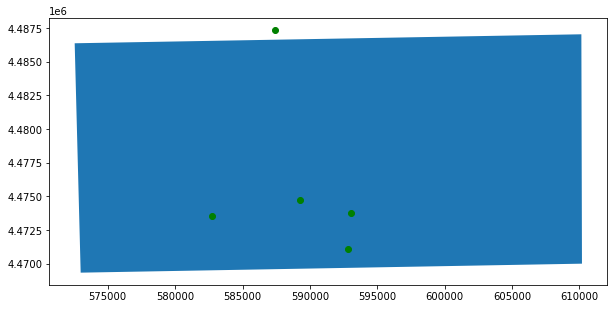

In [30]:
fig, ax = plt.subplots(figsize=(10, 10))
clip_polygon.plot(ax = ax)
coll_road.head().plot(ax = ax, color = 'green')

In [52]:
coll_road_within[['CRASH_CRN', 'CRASH_YEAR', 'CRASH_MONTH', 'DAY_OF_WEEK', 'HOUR_OF_DAY',
       'LOCATION_TYPE', 'MAX_SEVERITY_LEVEL', 'LONGITUDE', 'LATITUDE',
       'SPEED_LIMIT', 'severity', 'carLane', 'bikeLane',
       'car.reverse', 'bike.reverse', 'foot_left', 'geometry', 'index_right',
       'Unnamed: 0', 'edge_id', 'source', 'target', 'car',
       'car reverse', 'bike', 'bike reverse', 'foot_right', 'length2',
       'length_direct_calc', 'dist_to_road', 'dist_to_int', 'straight_len', 'curve', 'curve_cut_off']].to_file('prepped_roads.shp')

C:\Users\cle9a\anaconda3\envs\rcp2Lite3\lib\site-packages\geopandas\io\file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,
C:\Users\cle9a\AppData\Local\Temp\ipykernel_27448\1876844219.py:7: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  'length_direct_calc', 'dist_to_road', 'dist_to_int', 'straight_len', 'curve', 'curve_cut_off']].to_file('prepped_roads.shp')


In [53]:
coll_road.columns

Index(['CRASH_CRN', 'CRASH_YEAR', 'CRASH_MONTH', 'DAY_OF_WEEK', 'HOUR_OF_DAY',
       'LOCATION_TYPE', 'MAX_SEVERITY_LEVEL', 'LONGITUDE', 'LATITUDE',
       'SPEED_LIMIT', 'severity', 'carLane', 'bikeLane', 'streetLength',
       'car.reverse', 'bike.reverse', 'foot_left', 'geometry', 'index_right',
       'Unnamed: 0', 'edge_id', 'source', 'target', 'length', 'car',
       'car reverse', 'bike', 'bike reverse', 'foot_right', 'WKT', 'length2',
       'length_direct_calc', 'dist_to_road', 'end1', 'end2', 'end1_dist',
       'end2_dist', 'dist_to_int', 'straight_len', 'curve', 'curve_cut_off'],
      dtype='object')